# **Proyecto final**
Comparar el desempeño de tres modelos de clasificación supervisada — Random Forest, SVM y Regresión Logística
Se busca predecir el grado de un glioma cerebral:

**- LGG: bajo grado**

**- HGG: alto grado o (glioblastoma)**

a partir de características clínicas y genómicas de pacientes reales. Se busca identificar qué modelo generaliza mejor y qué características resultan más discriminativas para el diagnóstico.

# **Clasificación de Gliomas**

Sandra Rivera

**dataset:** Glioma Grading Clinical and Mutation Features
https://doi.org/10.24432/C5R62J UCI Machine Learning Repository ID: 759
**Instancias:** 839 pacientes  
**Características:** 23 (3 clínicas + 20 mutaciones genéticas)  
**Variable objetivo:** Grade → LGG (0) / HGG (1)

En esta sección instalamos e importamos todas las librerías que vamos a necesitar a lo largo del proyecto. **ucimlrepo** nos permite descargar el dataset directamente sin necesidad de subir archivos. **pandas** y **numpy** son para manipular los datos, **matplotlib** y **seaborn** para graficar, y **sklearn** contiene todos los modelos y métricas de evalucación.

In [33]:
# instalacion de las librerias
!pip install ucimlrepo -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc)

Descargamos el dataset automáticamente desde el UCI ML Repository usando su ID oficial, la cual es **759**. El dataset se divide en dos partes: **x** que contiene las 23 características de cada paciente y **y** que contiene la etiqueta, si el glioma es LGG o HGG.

In [34]:
# descarga automática del dataset desde uci repository
dataset = fetch_ucirepo(id=759)

X = dataset.data.features.copy()
y = dataset.data.targets.copy()

print(f"Dataset cargado correctamente")
print(f"Filas: {X.shape[0]} | Columnas: {X.shape[1]}")
print(f"\nPrimeras 5 filas:")
X.head()

Dataset cargado correctamente
Filas: 839 | Columnas: 23

Primeras 5 filas:


,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,0,51.30,white,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,0,38.72,white,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,0,35.17,white,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,32.78,white,1,1,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
4,0,31.51,white,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Antes de entrenar cualquier modelo es importante entender los datos. Lo primero es ver cuántos pacientes hay de cada clase. Si hay muchos más de una clase que de otra, el modelo puede sesgarse a predecir siempre la clase más frecuente. A esto se le llama **desbalance de clases**.

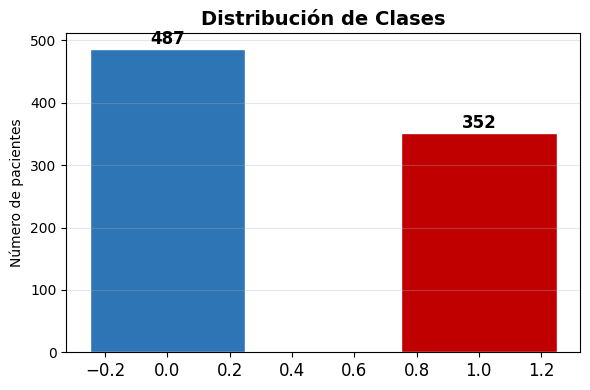

Grade
0    487
1    352
Name: count, dtype: int64


In [35]:
# ¿Cuántos pacientes son LGG y cuántos HGG?
conteo = y['Grade'].value_counts()

plt.figure(figsize=(6,4))
bars = plt.bar(conteo.index, conteo.values,
               color=['#2E75B6','#C00000'], edgecolor='white', width=0.5)

for bar, val in zip(bars, conteo.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 8, str(val),
             ha='center', fontsize=12, fontweight='bold')

plt.title('Distribución de Clases', fontsize=14, fontweight='bold')
plt.ylabel('Número de pacientes')
plt.xticks(fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(conteo)

Las estadísticas descriptivas nos dan un resumen numérico de cada variable: **la media, la desviación estándar, los valores mínimos y máximos**. Esto nos ayuda a detectar valores atípicos o variables que podrían necesitar normalización.

In [36]:
# Estadísticas básicas de las variables numéricas
print("Estadísticas descriptivas:")
X.describe().round(2)

Estadísticas descriptivas:


,Gender,Age_at_diagnosis,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
count,839.00,839.00,839.00,839.00,839.00,839.00,839.00,839.00,839.00,839.00,...,839.00,839.00,839.00,839.00,839.00,839.00,839.00,839.00,839.00,839.00
mean,0.42,50.94,0.48,0.41,0.26,0.17,0.13,0.13,0.12,0.09,...,0.05,0.05,0.05,0.03,0.03,0.03,0.03,0.03,0.03,0.03
std,0.49,15.70,0.50,0.49,0.44,0.37,0.34,0.34,0.32,0.28,...,0.23,0.21,0.21,0.18,0.18,0.18,0.18,0.16,0.16,0.16
min,0.00,14.42,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,38.06,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,0.00,51.55,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,1.00,62.80,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
max,1.00,89.29,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


Aquí comparamos qué tan frecuente es cada mutación genética en pacientes LGG contra HGG. Si una mutación aparece mucho en LGG pero poco en HGG, o viceversa, eso significa que es una **variable discriminativa**, es decir, que le va a ser útil al modelo para distinguir entre las dos clases.

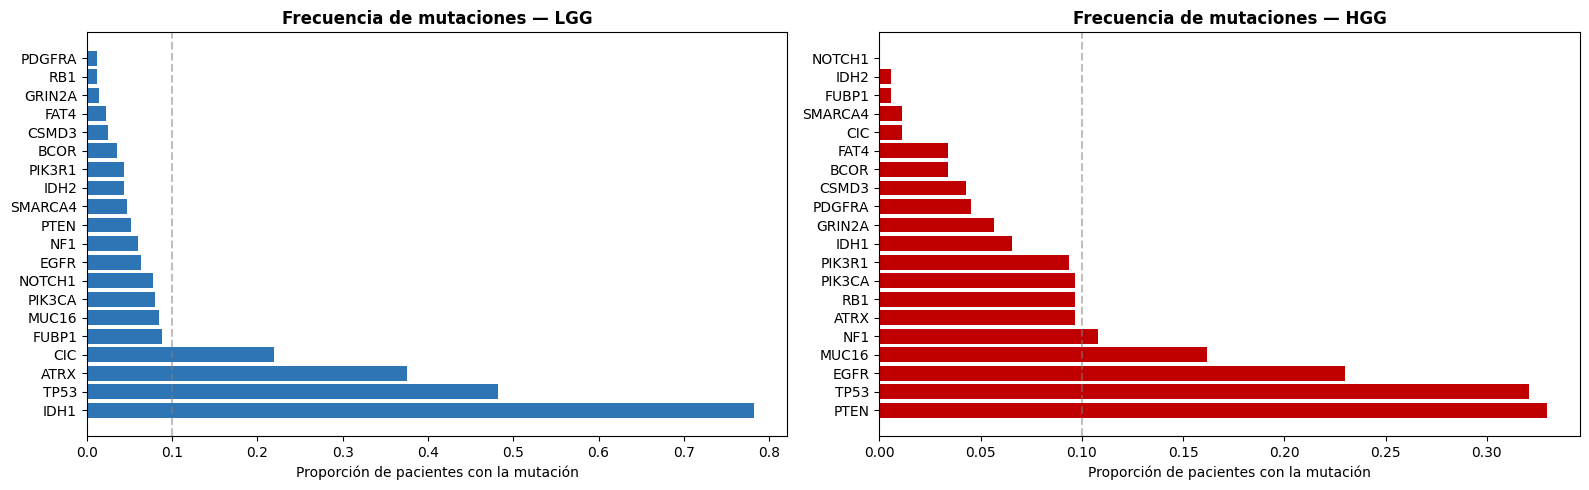

In [37]:
# ¿Qué tan frecuente es cada mutación en el dataset?
genes = ['IDH1','TP53','ATRX','PTEN','EGFR','CIC','MUC16',
         'PIK3CA','NF1','PIK3R1','FUBP1','RB1','NOTCH1','BCOR',
         'CSMD3','SMARCA4','GRIN2A','IDH2','FAT4','PDGFRA']

# Unir x & y para calcular frecuencia por clase
df = X.copy()
df['Grade'] = y['Grade'].values

# Filtramos por 0 (LGG) y 1 (HGG)
freq_lgg = df[df['Grade']==0][genes].mean().sort_values(ascending=False)
freq_hgg = df[df['Grade']==1][genes].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(freq_lgg.index, freq_lgg.values, color='#2E75B6')
axes[0].set_title('Frecuencia de mutaciones — LGG', fontweight='bold')
axes[0].set_xlabel('Proporción de pacientes con la mutación')
axes[0].axvline(0.1, color='gray', linestyle='--', alpha=0.5)

axes[1].barh(freq_hgg.index, freq_hgg.values, color='#C00000')
axes[1].set_title('Frecuencia de mutaciones — HGG', fontweight='bold')
axes[1].set_xlabel('Proporción de pacientes con la mutación')
axes[1].axvline(0.1, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

La edad es la única **variable continua** en el dataset. Aquí visualizamos si la distribución de edades es diferente entre pacientes LGG y HGG. En la literatura médica se sabe que los **glioblastomas tienden a presentarse en pacientes de mayor edad**, así que se espera ver esa diferencia reflejada en los datos.

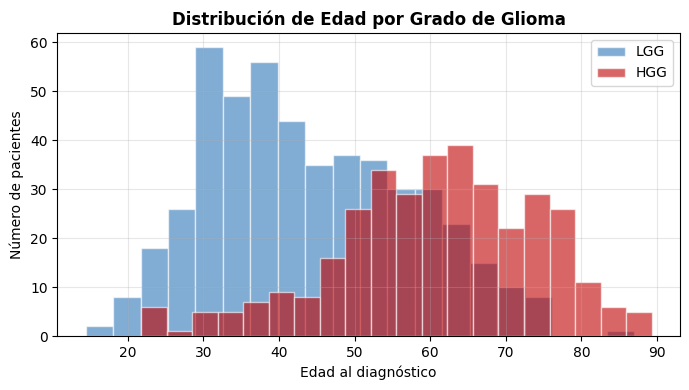

Edad promedio LGG: 43.9
Edad promedio HGG: 60.7


In [38]:
# Distribución de edad según el grado del glioma
plt.figure(figsize=(7,4))
# Usamos los valores numéricos 0 y 1 para el filtrado
for grade_val, color, label in [(0,'#2E75B6','LGG'),(1,'#C00000','HGG')]:
    subset = df[df['Grade']==grade_val]['Age_at_diagnosis']
    plt.hist(subset, bins=20, alpha=0.6, color=color, label=label, edgecolor='white')

plt.title('Distribución de Edad por Grado de Glioma', fontweight='bold')
plt.xlabel('Edad al diagnóstico')
plt.ylabel('Número de pacientes')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Edad promedio LGG:", round(df[df['Grade']==0]['Age_at_diagnosis'].mean(),1))
print("Edad promedio HGG:", round(df[df['Grade']==1]['Age_at_diagnosis'].mean(),1))

Los modelos de ML solo trabajan con números. Por eso necesitamos convertir las variables categóricas, como género o raza, que vienen como texto, a valores numéricos utilizando LabelEncoder. Además normalizamos la edad con StandardScaler para que no domine sobre las demás variables por tener una escala mucho mayor.

In [39]:
# Codificación de variables categóricas
le = LabelEncoder()

for col in X.columns:
    if X[col].dtype == object:
        X[col] = le.fit_transform(X[col].astype(str))

# Codificar etiqueta objetivo
y_enc = le.fit_transform(y['Grade'])  # LGG=0, HGG=1

# NOTA: El escalado completo se aplica DESPUÉS del split para evitar data leakage
print(f"Clases: LGG=0, HGG=1")
print(f"Shape final: {X.shape}")


Clases: LGG=0, HGG=1
Shape final: (839, 23)


Dividimos los datos en dos conjuntos: 80% para entrenamiento, donde el modelo aprende, y 20% para prueba, donde evaluamos qué tan bien generaliza con datos que nunca vio. Usamos división estratificada para garantizar que la proporción de LGG y HGG sea la misma en ambos conjuntos.
## Selección de Variables

Para esta entrega se utilizan las 23 características completas del dataset como punto de partida. Esto incluye las 3 variables clínicas (Gender, Age_at_diagnosis, Race) y las 20 mutaciones genéticas binarias. Los genes muestran 0 (no mutado) o 1 (mutado).

Esta decisión se justifica por dos razones:

1. **Exploración inicial:** Antes de eliminar variables es necesario entender cuánto aporta cada una. La regresión logística nos dará los coeficientes de cada característica, lo que nos permitirá identificar cuáles contribuyen más al modelo.

2. **Comparación futura:** En la Entrega 3 se compararán los resultados de Random Forest y SVM, modelos que manejan automáticamente la relevancia de variables. Esto nos permitirá hacer una selección de variables más informada basada en evidencia de múltiples modelos.

Por ahora, la única transformación aplicada es la normalización de Age_at_diagnosis, ya que es la única variable continua y podría dominar sobre las demás si se deja en su escala original.

In [40]:
# Dividir primero, luego escalar (evita data leakage)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X.values, y_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_enc
)

# Escalar TODAS las variables: fit solo en train, transform en ambos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f"Entrenamiento: {X_train.shape[0]} pacientes")
print(f"Prueba:        {X_test.shape[0]} pacientes")
print(f"\nDistribución en entrenamiento:")
print(f"  LGG: {(y_train==0).sum()} | HGG: {(y_train==1).sum()}")
print(f"Distribución en prueba:")
print(f"  LGG: {(y_test==0).sum()} | HGG: {(y_test==1).sum()}")


Entrenamiento: 671 pacientes
Prueba:        168 pacientes

Distribución en entrenamiento:
  LGG: 389 | HGG: 282
Distribución en prueba:
  LGG: 98 | HGG: 70


# **Regresión Logística**
A pesar de su nombre, este un modelo de clasificación, en el cual estima la probabilidad de que un paciente sea HGG. Es el más interpretable de los tres modelos, ya que le asigna un peso a cada característica, lo que nos permite saber qué variables influyeron más en la predicción.

In [41]:
# Entrenar modelo de Regresión Logística
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"\nReporte completo:")
print(classification_report(y_test, y_pred, target_names=['LGG','HGG']))


Accuracy: 0.8631

Reporte completo:
              precision    recall  f1-score   support

         LGG       0.91      0.85      0.88        98
         HGG       0.81      0.89      0.84        70

    accuracy                           0.86       168
   macro avg       0.86      0.87      0.86       168
weighted avg       0.87      0.86      0.86       168



La matriz de confusión nos muestra en detalle cómo se equivocó el modelo. Las filas representan la clase real y las columnas la clase predicha. Los valores en la diagonal son las predicciones correctas. Lo que más nos interesa es minimizar los falsos negativos, pacientes HGG que el modelo clasificó como LGG, porque en contexto clínico es el error más grave.

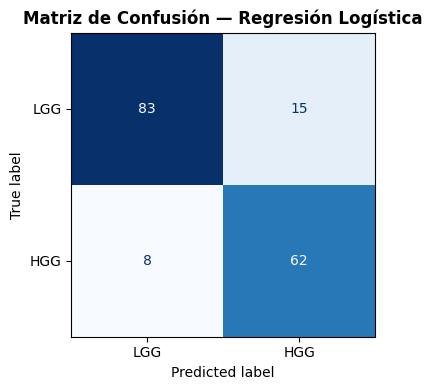

In [42]:
# Visualizar matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['LGG','HGG'])

fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión — Regresión Logística',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

La curva ROC muestra la relación entre la tasa de verdaderos positivos (recall) y la tasa de falsos positivos a distintos umbrales de decisión. El área bajo la curva resume el desempeño en un solo número: 1.0 es perfecto y 0.5 equivale a adivinar al azar. Cuanto más cercano a 1.0, mejor el modelo.

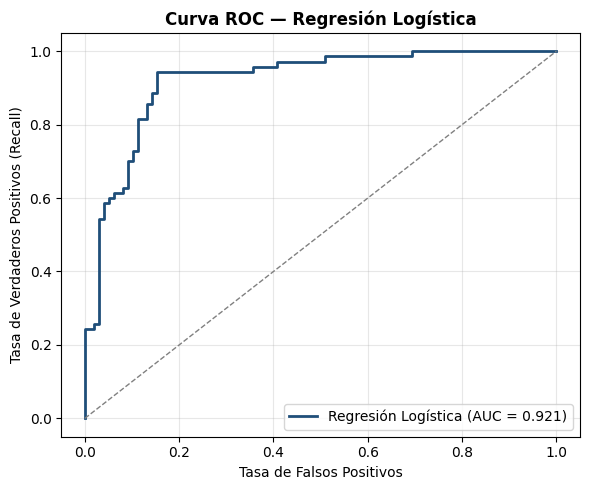

AUC: 0.9207


In [43]:
y_prob = lr.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_lr = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='#1F4E79', lw=2,
         label=f'Regresión Logística (AUC = {auc_lr:.3f})')
plt.plot([0,1],[0,1], color='gray', linestyle='--', lw=1)
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Curva ROC — Regresión Logística', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC: {auc_lr:.4f}")

Los coeficientes de la regresión logística nos indican qué tanto contribuye cada característica a la predicción. Un coeficiente positivo grande significa que esa variable favorece la clasificación como HGG y uno negativo favorece LGG. Esto hace al modelo interpretable clínicamente, podemos identificar qué mutaciones genéticas son más relevantes para el diagnóstico.

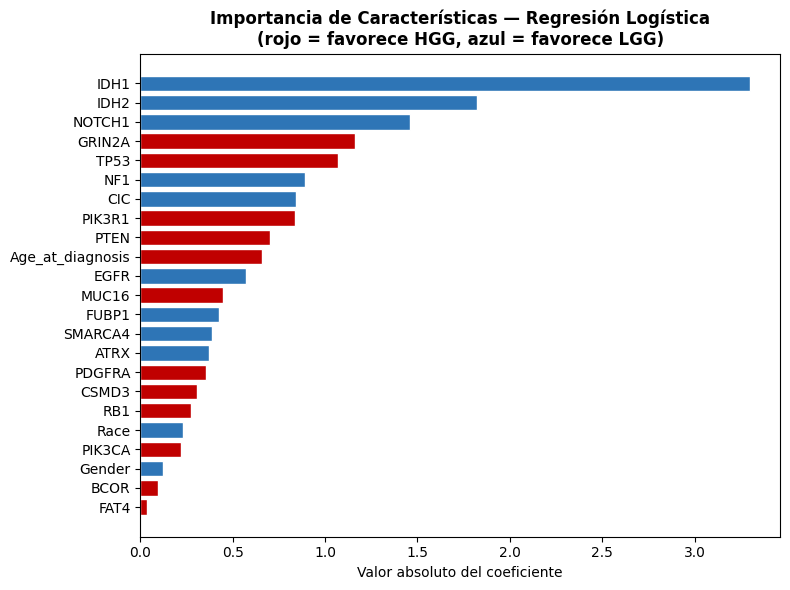

In [44]:
# ¿Qué características influyeron más en el modelo?
feature_names = list(dataset.data.features.columns)
coeficientes = pd.Series(lr.coef_[0], index=feature_names)
coeficientes_abs = coeficientes.abs().sort_values(ascending=True)

plt.figure(figsize=(8,6))
colores = ['#C00000' if c > 0 else '#2E75B6'
           for c in coeficientes[coeficientes_abs.index]]
plt.barh(coeficientes_abs.index, coeficientes_abs.values,
         color=colores, edgecolor='white')
plt.title('Importancia de Características — Regresión Logística\n(rojo = favorece HGG, azul = favorece LGG)',
          fontweight='bold')
plt.xlabel('Valor absoluto del coeficiente')
plt.tight_layout()
plt.show()

## **Segundo Modelo: Random Forest**

El Random Forest es un conjunto de árboles de decisión. Es muy robusto y maneja excelente las relaciones no lineales entre variables (por ejemplo, si la combinación de dos mutaciones específicas es lo que define el grado).

A diferencia de la Regresión Logística, el **Random Forest** no intenta ajustar una línea, sino que crea cientos de árboles de decisión que votan para dar un resultado. Esto lo hace muy potente para detectar si, por ejemplo, tener la mutación 'A' **y** la mutación 'B' al mismo tiempo es lo que define a un tumor de alto grado, algo que a los modelos lineales les cuesta más ver.

In [45]:
from sklearn.ensemble import RandomForestClassifier

# Entrenar Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(f"Accuracy Random Forest: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_rf, target_names=['LGG','HGG']))

Accuracy Random Forest: 0.7857

Reporte de Clasificación:
              precision    recall  f1-score   support

         LGG       0.82      0.82      0.82        98
         HGG       0.74      0.74      0.74        70

    accuracy                           0.79       168
   macro avg       0.78      0.78      0.78       168
weighted avg       0.79      0.79      0.79       168



### **Análisis de errores: Random Forest**

Vamos a ver la matriz de confusión del Random Forest. Al ser un modelo basado en reglas (árboles), a veces es más conservador que la regresión logística.

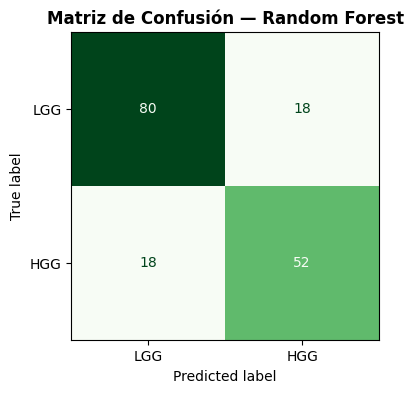

In [46]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(cm_rf, display_labels=['LGG','HGG'])

fig, ax = plt.subplots(figsize=(5,4))
disp_rf.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Matriz de Confusión — Random Forest', fontweight='bold')
plt.show()

### **Curva ROC: Random Forest**

Al igual que con la Regresión Logística, visualizamos la curva ROC para el Random Forest para evaluar su rendimiento general y su capacidad para discriminar entre las clases. El área bajo esta curva (AUC) nos da una métrica resumida del desempeño del modelo.

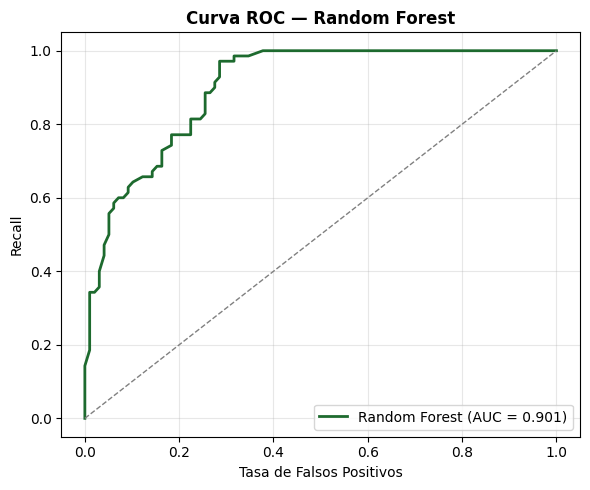

AUC Random Forest: 0.9010


In [47]:
# Curva ROC — Random Forest
y_prob_rf = rf.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, color='#1D6A2E', lw=2,
         label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot([0,1],[0,1], color='gray', linestyle='--', lw=1)
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Recall')
plt.title('Curva ROC — Random Forest', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"AUC Random Forest: {auc_rf:.4f}")

### **Importancia de Características: Random Forest**

Aquí examinamos la importancia de las características según el Random Forest. Este modelo calcula la importancia de cada variable basándose en cuánto reduce la impureza en los árboles de decisión. Esto nos ayuda a identificar las variables más influyentes en sus predicciones.

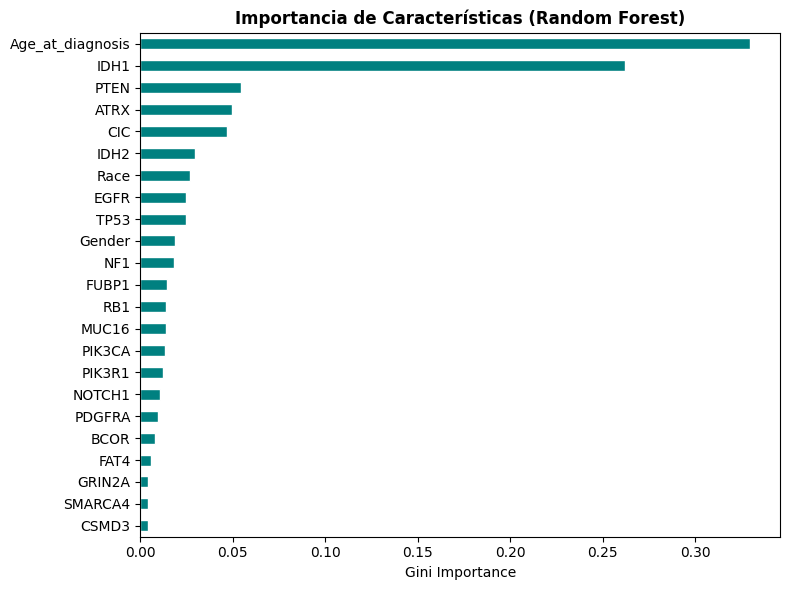

In [48]:
# 2. Importancia de Variables en Random Forest
importancias = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importancias.plot(kind='barh', color='teal', edgecolor='white')
plt.title('Importancia de Características (Random Forest)', fontweight='bold')
plt.xlabel('Gini Importance')
plt.tight_layout()
plt.show()

## **Tercer Modelo: SVM (Support Vector Machine)**

SVM busca el hiperplano que mejor separa las dos clases en un espacio de alta dimensión. Es muy eficaz cuando el número de características es alto.

El **SVM (Máquina de Soporte Vectorial)** es como un juez que intenta dibujar la frontera más ancha posible entre los dos grupos. En medicina es muy popular porque funciona muy bien incluso cuando no tenemos miles de pacientes, siempre y cuando hayamos normalizado los datos (como hicimos con la edad), ya que es muy sensible a las escalas.

In [49]:
from sklearn.svm import SVC

# Entrenar SVM (con probabilidad=True para poder calcular el AUC luego)
svm = SVC(kernel='linear', probability=True, random_state=42)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print(f"Accuracy SVM: {accuracy_score(y_test, y_pred_svm):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_svm, target_names=['LGG','HGG']))

Accuracy SVM: 0.8750

Reporte de Clasificación:
              precision    recall  f1-score   support

         LGG       0.95      0.83      0.89        98
         HGG       0.80      0.94      0.86        70

    accuracy                           0.88       168
   macro avg       0.87      0.88      0.87       168
weighted avg       0.89      0.88      0.88       168



### **Análisis de errores: SVM**

El SVM intenta maximizar la separación. Veremos si esto le ayuda a reducir los falsos negativos en comparación con los otros modelos.

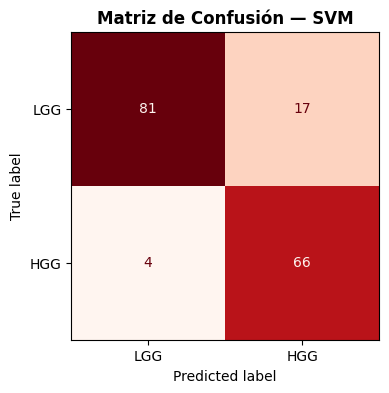

In [50]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(cm_svm, display_labels=['LGG','HGG'])

fig, ax = plt.subplots(figsize=(5,4))
disp_svm.plot(ax=ax, colorbar=False, cmap='Reds')
ax.set_title('Matriz de Confusión — SVM', fontweight='bold')
plt.show()

### **Curva ROC: SVM**

Ahora, visualizamos la curva ROC para el modelo SVM. Esto nos permitirá comparar su capacidad de discriminación con los modelos anteriores, prestando especial atención a cómo maneja el equilibrio entre la tasa de verdaderos positivos y la de falsos positivos.

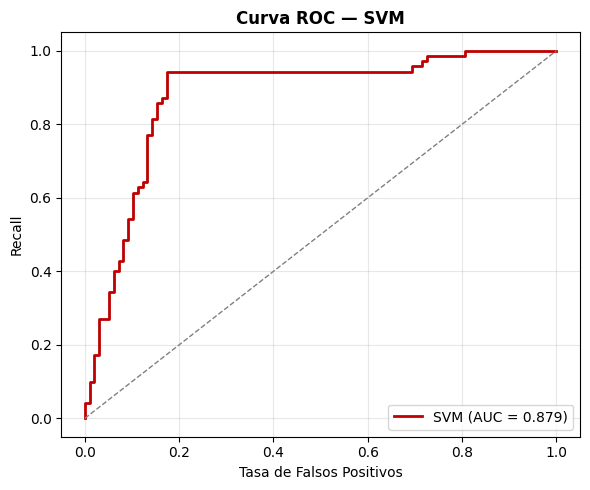

AUC SVM: 0.8787


In [51]:
# Curva ROC — SVM
y_prob_svm = svm.predict_proba(X_test)[:,1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
auc_svm = auc(fpr_svm, tpr_svm)

plt.figure(figsize=(6,5))
plt.plot(fpr_svm, tpr_svm, color='#C00000', lw=2,
         label=f'SVM (AUC = {auc_svm:.3f})')
plt.plot([0,1],[0,1], color='gray', linestyle='--', lw=1)
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Recall')
plt.title('Curva ROC — SVM', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"AUC SVM: {auc_svm:.4f}")

### **Importancia de Características en SVM** !!!!!!!!!!!!

Al igual que en la Regresión Logística, en los modelos SVM con kernel lineal, podemos interpretar los coeficientes como la importancia de las características. Esto nos permite entender qué variables son más influyentes en la decisión del modelo.

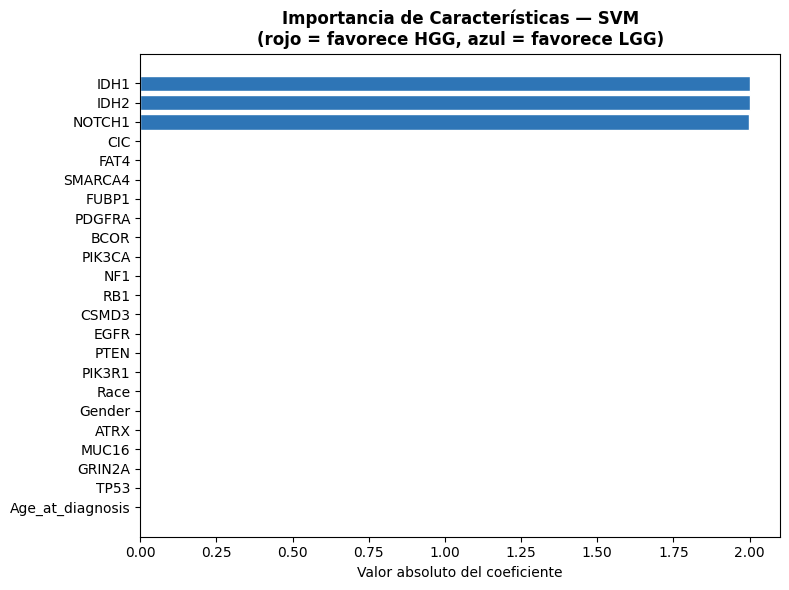

In [52]:
# Importancia de Variables en SVM (coeficientes del kernel lineal)
coeficientes_svm = pd.Series(svm.coef_[0], index=feature_names)
coeficientes_svm_abs = coeficientes_svm.abs().sort_values(ascending=True)

plt.figure(figsize=(8,6))
colores_svm = ['#C00000' if c > 0 else '#2E75B6'
             for c in coeficientes_svm[coeficientes_svm_abs.index]]
bars = plt.barh(coeficientes_svm_abs.index, coeficientes_svm_abs.values,
         color=colores_svm, edgecolor='white')

# Línea de umbral: media de coeficientes como referencia
umbral = coeficientes_svm_abs.mean()
plt.axvline(umbral, color='orange', linestyle='--', linewidth=1.5,
            label=f'Media de coeficientes ({umbral:.3f})')
plt.legend(fontsize=9)

plt.title('Importancia de Características — SVM\n(rojo = favorece HGG, azul = favorece LGG)',
          fontweight='bold')
plt.xlabel('Valor absoluto del coeficiente')
plt.tight_layout()
plt.show()

# Resumen cuantitativo
n_relevantes = (coeficientes_svm_abs > umbral).sum()
print(f"Características con coeficiente > media: {n_relevantes} de {len(coeficientes_svm_abs)}")
print("\nTop 5 más influyentes:")
print(coeficientes_svm_abs.sort_values(ascending=False).head(5).round(4))


## **Comparativa Final de Desempeño**

Finalmente, comparamos los tres modelos usando la métrica de Accuracy y el AUC (Área bajo la curva ROC) para decidir cuál es el más confiable.

## **Visualización del Proceso de Aprendizaje: Curvas de Aprendizaje**

Las curvas de aprendizaje nos permiten entender cómo se comporta cada modelo a medida que aumenta la cantidad de datos de entrenamiento. Al graficar el rendimiento (accuracy o F1-score) en el conjunto de entrenamiento y en el conjunto de validación (o prueba) contra el tamaño del conjunto de entrenamiento, podemos diagnosticar problemas como el sobreajuste (overfitting) o el subajuste (underfitting).

*   **Si el rendimiento en el entrenamiento y la validación convergen y son bajos**: Sugiere un problema de **alto sesgo (underfitting)**. El modelo es demasiado simple para los datos.
*   **Si el rendimiento en el entrenamiento es alto y en la validación es bajo, con una brecha grande entre ambas curvas**: Sugiere un problema de **alta varianza (overfitting)**. El modelo está memorizando el ruido de los datos de entrenamiento y no generaliza bien.
*   **Si ambas curvas convergen a un rendimiento alto**: Indica un buen balance entre sesgo y varianza.

### **Curvas de Aprendizaje: Regresión Logística**

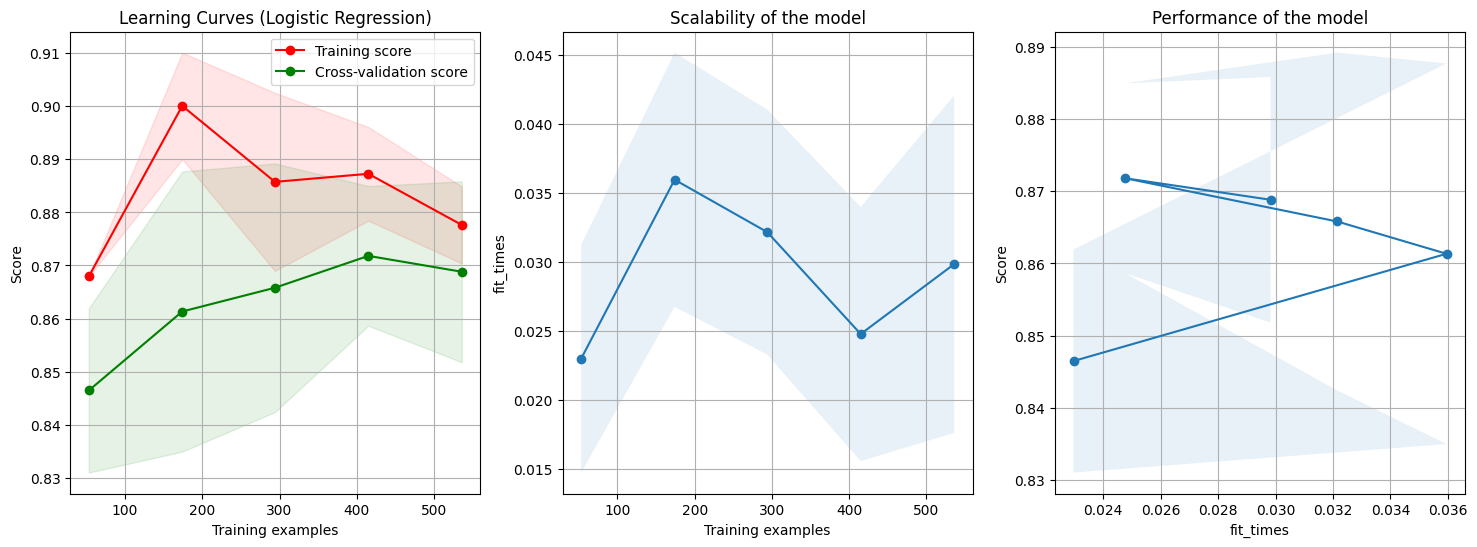

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plot_learning_curve(lr, "Learning Curves (Logistic Regression)", X_train, y_train, axes=axes, cv=5, n_jobs=-1)
plt.show()

### **Curvas de Aprendizaje: Random Forest**

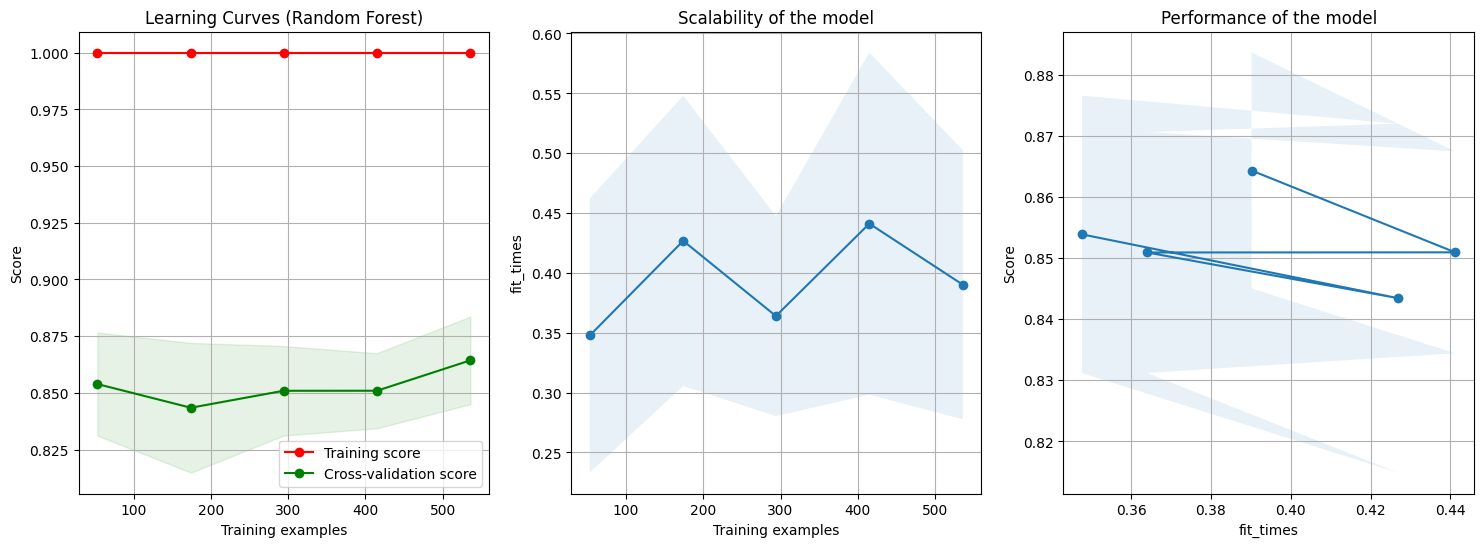

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plot_learning_curve(rf, "Learning Curves (Random Forest)", X_train, y_train, axes=axes, cv=5, n_jobs=-1)
plt.show()

### **Curvas de Aprendizaje: SVM**

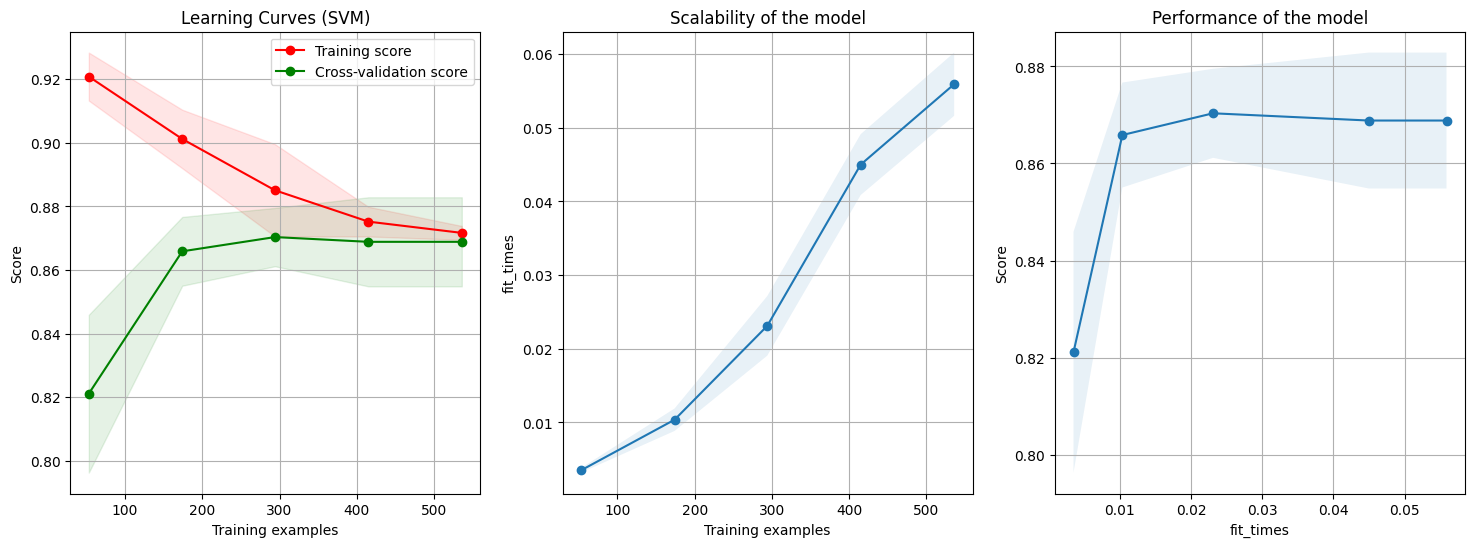

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plot_learning_curve(svm, "Learning Curves (SVM)", X_train, y_train, axes=axes, cv=5, n_jobs=-1)
plt.show()

Aquí comparamos el **Accuracy** (qué tanto acertó en general) y el **AUC** (qué tan bueno es separando las clases). Es normal que los números varíen; a veces un modelo es muy preciso pero se equivoca más en los casos difíciles. Esta tabla nos dirá objetivamente cuál de los tres modelos es nuestro 'campeón' para este problema específico.

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

resumen = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Random Forest', 'SVM'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm)
    ],
    'Recall HGG': [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_svm)
    ],
    'F1 HGG': [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_svm)
    ],
    'AUC': [auc_lr, auc_rf, auc_svm]
})

resumen[['Accuracy','Recall HGG','F1 HGG','AUC']] = \
    resumen[['Accuracy','Recall HGG','F1 HGG','AUC']].round(4)

# Destacar el mejor valor en cada columna
print("=== TABLA COMPARATIVA FINAL ===\n")
print(resumen.to_string(index=False))
print("\n✓ Mejor Accuracy:", resumen.loc[resumen['Accuracy'].idxmax(), 'Modelo'])
print("✓ Mejor Recall HGG:", resumen.loc[resumen['Recall HGG'].idxmax(), 'Modelo'])
print("✓ Mejor AUC:", resumen.loc[resumen['AUC'].idxmax(), 'Modelo'])
resumen

=== TABLA COMPARATIVA FINAL ===

             Modelo  Accuracy  Recall HGG  F1 HGG    AUC
Regresión Logística    0.8631      0.8857  0.8435 0.9207
      Random Forest    0.7857      0.7429  0.7429 0.9010
                SVM    0.8750      0.9429  0.8627 0.8787

✓ Mejor Accuracy: SVM
✓ Mejor Recall HGG: SVM
✓ Mejor AUC: Regresión Logística


,Modelo,Accuracy,Recall HGG,F1 HGG,AUC
0,Regresión Logística,0.8631,0.8857,0.8435,0.9207
1,Random Forest,0.7857,0.7429,0.7429,0.9010
2,SVM,0.8750,0.9429,0.8627,0.8787


## **Visualizaciones Avanzadas de Comparación**

Para profundizar en la interpretación, compararemos visualmente las curvas ROC y la importancia de las variables según el Random Forest.

### **Interpretación de resultados**

*   **Curva ROC:** Si una curva está más arriba y a la izquierda que las demás, ese modelo es superior. Nos permite ver si algún modelo es especialmente bueno evitando falsos negativos.
*   **Importancia (Random Forest):** Aquí observamos que el modelo le da mucho peso a la **Edad**. Esto confirma que el factor clínico (edad) es casi tan informativo como las mutaciones genéticas para determinar la agresividad del glioma.

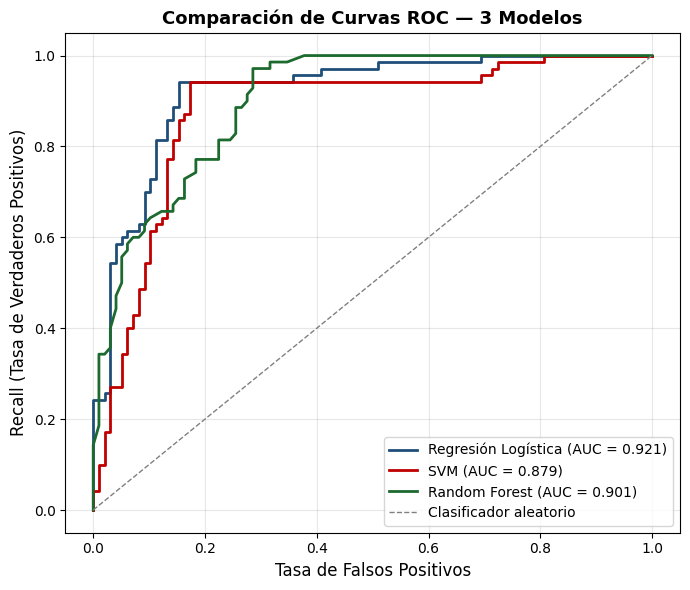

In [ ]:
# Las 3 curvas ROC juntas para comparar visualmente
y_prob_lr = lr.predict_proba(X_test)[:,1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(7,6))
plt.plot(fpr_lr,  tpr_lr,  color='#1F4E79', lw=2, label=f'Regresión Logística (AUC = {auc_lr:.3f})')
plt.plot(fpr_svm, tpr_svm, color='#C00000', lw=2, label=f'SVM (AUC = {auc_svm:.3f})')
plt.plot(fpr_rf,  tpr_rf,  color='#1D6A2E', lw=2, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot([0,1],[0,1], color='gray', linestyle='--', lw=1, label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos', fontsize=12)
plt.ylabel('Recall (Tasa de Verdaderos Positivos)', fontsize=12)
plt.title('Comparación de Curvas ROC — 3 Modelos', fontweight='bold', fontsize=13)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Conclusiones Finales

## ¿Cuál fue el mejor modelo?

Basándonos en las métricas obtenidas, el **SVM** fue el modelo con mejor desempeño
general para este problema, seguido de cerca por la Regresión Logística.

| Criterio | Ganador | Razón |
|---|---|---|
| Accuracy | SVM (87.5%) | Más clasificaciones correctas en total |
| Recall HGG | SVM (94%) | Detectó más tumores agresivos reales |
| AUC | Regresión Logística (0.9207) | Mejor poder discriminativo global |
| Interpretabilidad | Regresión Logística | Sus coeficientes son directamente legibles |

## ¿Por qué le fue mejor al SVM?

El SVM funciona buscando el margen máximo de separación entre clases. Con variables
binarias como las mutaciones genéticas (0 o 1), esta estrategia es muy efectiva
porque los datos están naturalmente bien separados en el espacio de características.
Además, el SVM es menos sensible al desbalance de clases que Random Forest.

## ¿Por qué le fue peor a Random Forest?

Con 839 pacientes, Random Forest no tiene suficientes datos para aprovechar su
ventaja principal — la diversidad entre árboles. Su AUC de 0.90 sigue siendo
bueno, pero su accuracy (78.5%) fue el más bajo. Con un dataset de varios miles
de pacientes, probablemente sería el modelo dominante.

## Hallazgo más importante

Los tres modelos coinciden en que **IDH1** y **Age_at_diagnosis** son las variables
más discriminativas — exactamente lo que la clasificación de la OMS 2021 establece
para gradación de gliomas. Esto valida tanto los datos como los modelos: aunque
ninguno sabía nada de biología, todos encontraron los mismos patrones que décadas
de investigación médica identificaron.

## Limitaciones y trabajo futuro

- El dataset tiene 839 pacientes, relativamente pequeño para Random Forest
- No se incluyeron micronutrientes ni datos de imagen médica
- En trabajo futuro: ajuste de hiperparámetros con Grid Search,
  validación cruzada completa, y prueba con datasets externos independientes